# 03: Mediation Estimands and Assumptions for Discovery Quality

The previous notebook created explicit discovery-quality metrics. This notebook turns those metrics into a causal mediation design.

The core question moves from association with future engagement to pathway evidence. The sharper question asks **through what pathway discovery exposure relates to future user value.** A discovery-heavy day can affect future behavior in at least two ways:

- A **direct pathway**, where discovery exposure itself changes future engagement because the user sees broader or less obvious content.
- An **indirect pathway**, where discovery exposure first changes satisfaction depth, and satisfaction depth then changes future engagement.

This notebook defines those pathways carefully before estimating them. It specifies the treatment, mediator, outcome, candidate controls, assumptions, and diagnostics needed for later direct/indirect effect estimation. The code also saves a clean mediation analysis panel so the next notebook can focus on estimation.

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

The data come from a real observational recommendation log. Discovery exposure, satisfaction depth, and future engagement arise from platform behavior, so the mediation analysis needs explicit identifying assumptions. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook defines the mediation estimands, temporal ordering, adjustment set, overlap checks, and key assumptions needed for interpretation.

<!-- mathematical-setup -->

## Mathematical Setup

The total effect can be decomposed into natural direct and indirect effects under mediation assumptions. Using potential outcomes \(Y_i(a,m)\) and mediator potential outcomes \(M_i(a)\), the natural indirect effect is

$$
\operatorname{NIE}=\mathbb{E}\left[Y_i(1,M_i(1))-Y_i(1,M_i(0))\right],
$$

and the natural direct effect is

$$
\operatorname{NDE}=\mathbb{E}\left[Y_i(1,M_i(0))-Y_i(0,M_i(0))\right].
$$

Together they add to the total effect on the additive scale:

$$
\operatorname{TE}=\operatorname{NDE}+\operatorname{NIE}.
$$

The assumptions are strong because treatment, mediator, and outcome must be ordered in time and their confounding must be addressed.


#### 1. Load Libraries and Define Paths

This cell imports the libraries needed for data preparation, diagnostic modeling, and plotting. It also defines all input and output paths. The root-detection logic makes the notebook work whether it is run from the repository root or directly from the notebook folder.

In [1]:
# Load libraries and define paths.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"


METRIC_PANEL_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_panel.parquet"
SELECTED_METRICS_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_selected_metrics.csv"
METRIC_VALIDATION_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_validation.csv"

MEDIATION_ANALYSIS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_analysis_panel.parquet"
ESTIMAND_REGISTRY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_estimand_registry.csv"
ASSUMPTION_CHECKS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_assumption_checks.csv"
BALANCE_TABLE_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_balance_table.csv"
OVERLAP_SUMMARY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_overlap_summary.csv"
MODEL_BLUEPRINT_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_model_blueprint.csv"


The path setup follows the same convention as earlier notebooks: reusable data goes to `data/processed`. That makes later notebooks independent of hidden notebook state.

#### 2. Load the Metric Panel

This cell loads the metric panel from the previous notebook and the metric-selection table that tells us which metric has which causal role. The selected metric table is important because it prevents accidental mixing of exposure, mediator, and monitoring metrics.

In [2]:
metric_panel = pd.read_parquet(METRIC_PANEL_INPUT)
selected_metrics = pd.read_csv(SELECTED_METRICS_INPUT)
metric_validation = pd.read_csv(METRIC_VALIDATION_INPUT)

load_summary = pd.DataFrame(
    {
        "artifact": ["metric_panel", "selected_metrics", "metric_validation"],
        "rows": [len(metric_panel), len(selected_metrics), len(metric_validation)],
        "columns": [metric_panel.shape[1], selected_metrics.shape[1], metric_validation.shape[1]],
    }
)

display(load_summary)
display(selected_metrics)


,artifact,rows,columns
0,metric_panel,8199,92
1,selected_metrics,4,7
2,metric_validation,6,26


,selected_for,metric,reason,future_alignment_score,history_dependence_score,screening_score,top_minus_bottom_future_interactions
0,exposure_analysis,discovery_breadth_score,Purest discovery exposure score; does not use future outcomes or satisfaction depth as a defining component.,0.501517,0.400845,0.361221,368.237805
1,mediator_analysis,satisfaction_depth_score,Aggregates several same-day quality signals and is appropriate as a mediator candidate.,0.050954,0.046479,0.034687,-23.403659
2,product_metric_monitoring,quality_adjusted_discovery_score,"Requires both discovery breadth and satisfaction depth to be high, making it a useful composite quality metric.",0.492386,0.357445,0.367280,349.624390
3,guardrail_monitoring,shallow_click_pressure_score,"Flags high-volume days with low satisfaction, useful as a warning against click-only optimization.",0.331588,0.444003,0.176187,284.229268


The inputs confirm that the notebook is starting from the metric layer. The chosen exposure metric is `discovery_breadth_score`, the chosen mediator is `satisfaction_depth_score`, and the product-facing composite remains separate from the causal treatment definition.

## Mediation Design Workflow

### Define the Causal Variables

This cell creates the formal analysis variables used throughout the notebook:

- `A`: binary high-discovery exposure, based on whether `discovery_breadth_score` is above its median.
- `M`: satisfaction depth, the same-day mediator candidate.
- `Y`: future seven-day interactions, the primary future-value outcome.
- `Y_active_days` and `Y_play_hours`: alternate future-value outcomes.

The binary treatment is used for interpretability. It lets the next notebook describe effects as the contrast between high-discovery and lower-discovery user-days.

In [3]:
# Define the causal variables.
analysis_panel = metric_panel.copy().sort_values(["user_id", "event_date"]).reset_index(drop=True)

analysis_panel["A_high_discovery"] = analysis_panel["high_discovery_breadth_day"].astype("int8")
analysis_panel["M_satisfaction_depth"] = analysis_panel["satisfaction_depth_score"].astype(float)
analysis_panel["Y_future_interactions"] = analysis_panel["outcome_future_7day_interactions"].astype(float)
analysis_panel["Y_future_active_days"] = analysis_panel["outcome_future_7day_active_days"].astype(float)
analysis_panel["Y_future_play_hours"] = analysis_panel["outcome_future_7day_play_hours"].astype(float)

role_summary = pd.DataFrame(
    [
        {
            "symbol": "A",
            "analysis_column": "A_high_discovery",
            "source_column": "high_discovery_breadth_day",
            "role": "treatment",
            "meaning": "Active user-day is above the median discovery-breadth score.",
        },
        {
            "symbol": "M",
            "analysis_column": "M_satisfaction_depth",
            "source_column": "satisfaction_depth_score",
            "role": "mediator",
            "meaning": "Same-day satisfaction depth built from watch-quality signals.",
        },
        {
            "symbol": "Y",
            "analysis_column": "Y_future_interactions",
            "source_column": "outcome_future_7day_interactions",
            "role": "primary outcome",
            "meaning": "Future seven-day interaction count after the current day.",
        },
        {
            "symbol": "Y_alt_1",
            "analysis_column": "Y_future_active_days",
            "source_column": "outcome_future_7day_active_days",
            "role": "alternate outcome",
            "meaning": "Future seven-day active-day count after the current day.",
        },
        {
            "symbol": "Y_alt_2",
            "analysis_column": "Y_future_play_hours",
            "source_column": "outcome_future_7day_play_hours",
            "role": "alternate outcome",
            "meaning": "Future seven-day play time in hours after the current day.",
        },
    ]
)

variable_summary = analysis_panel[
    ["A_high_discovery", "M_satisfaction_depth", "Y_future_interactions", "Y_future_active_days", "Y_future_play_hours"]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

display(role_summary)
display(variable_summary)


,symbol,analysis_column,source_column,role,meaning
0,A,A_high_discovery,high_discovery_breadth_day,treatment,Active user-day is above the median discovery-breadth score.
1,M,M_satisfaction_depth,satisfaction_depth_score,mediator,Same-day satisfaction depth built from watch-quality signals.
2,Y,Y_future_interactions,outcome_future_7day_interactions,primary outcome,Future seven-day interaction count after the current day.
3,Y_alt_1,Y_future_active_days,outcome_future_7day_active_days,alternate outcome,Future seven-day active-day count after the current day.
4,Y_alt_2,Y_future_play_hours,outcome_future_7day_play_hours,alternate outcome,Future seven-day play time in hours after the current day.


,count,mean,std,min,10%,25%,50%,75%,90%,max
A_high_discovery,8199.0,0.500061,0.500030,0.0,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
M_satisfaction_depth,8199.0,0.618626,0.112600,0.0,0.482869,0.547525,0.617436,0.685637,0.753525,1.000000
Y_future_interactions,8199.0,340.694475,180.363332,0.0,57.000000,206.000000,366.000000,471.000000,561.000000,899.000000
Y_future_active_days,8199.0,6.466398,1.456220,0.0,5.000000,7.000000,7.000000,7.000000,7.000000,7.000000
Y_future_play_hours,8199.0,0.818939,0.468145,0.0,0.142586,0.487289,0.825761,1.123796,1.400630,2.900588


The treatment is almost exactly balanced because it is median-based. The mediator has continuous variation, and the primary outcome has substantial spread. That combination is a good starting point for mediation: both pathways have room to vary.

### Write the Estimands Explicitly

This cell creates an estimand registry. The registry uses text to keep the assumptions readable before modeling. Later notebooks can estimate these quantities using regression, doubly robust methods, or g-computation.

The notation is:

- `Y(a, m)`: potential future outcome if treatment were set to `a` and mediator were set to `m`.
- `M(a)`: potential mediator value if treatment were set to `a`.
- `TE`: total effect of changing treatment from 0 to 1.
- `NDE`: natural direct effect through pathways other than the mediator.
- `NIE`: natural indirect effect through the mediator.

In [4]:
# Write the estimands explicitly.
estimand_registry = pd.DataFrame(
    [
        {
            "estimand": "total_effect",
            "symbol": "TE",
            "definition": "E[Y(1, M(1)) - Y(0, M(0))]",
            "plain_language": "Overall difference in future value between high-discovery and lower-discovery days.",
            "answers": "Does high discovery exposure relate to future value at all?",
        },
        {
            "estimand": "natural_direct_effect",
            "symbol": "NDE",
            "definition": "E[Y(1, M(0)) - Y(0, M(0))]",
            "plain_language": "Effect of high discovery exposure while holding the mediator at its lower-discovery counterfactual level.",
            "answers": "How much of the effect bypasses satisfaction depth?",
        },
        {
            "estimand": "natural_indirect_effect",
            "symbol": "NIE",
            "definition": "E[Y(1, M(1)) - Y(1, M(0))]",
            "plain_language": "Effect transmitted through the change in satisfaction depth caused by high discovery exposure.",
            "answers": "How much of the effect flows through satisfaction?",
        },
        {
            "estimand": "controlled_direct_effect_low_mediator",
            "symbol": "CDE_low",
            "definition": "E[Y(1, m_low) - Y(0, m_low)]",
            "plain_language": "Direct treatment contrast if satisfaction depth were fixed to a low reference value.",
            "answers": "What is the direct exposure effect under weak satisfaction?",
        },
        {
            "estimand": "controlled_direct_effect_high_mediator",
            "symbol": "CDE_high",
            "definition": "E[Y(1, m_high) - Y(0, m_high)]",
            "plain_language": "Direct treatment contrast if satisfaction depth were fixed to a high reference value.",
            "answers": "What is the direct exposure effect under strong satisfaction?",
        },
    ]
)

display(estimand_registry)


,estimand,symbol,definition,plain_language,answers
0,total_effect,TE,"E[Y(1, M(1)) - Y(0, M(0))]",Overall difference in future value between high-discovery and lower-discovery days.,Does high discovery exposure relate to future value at all?
1,natural_direct_effect,NDE,"E[Y(1, M(0)) - Y(0, M(0))]",Effect of high discovery exposure while holding the mediator at its lower-discovery counterfactual level.,How much of the effect bypasses satisfaction depth?
2,natural_indirect_effect,NIE,"E[Y(1, M(1)) - Y(1, M(0))]",Effect transmitted through the change in satisfaction depth caused by high discovery exposure.,How much of the effect flows through satisfaction?
3,controlled_direct_effect_low_mediator,CDE_low,"E[Y(1, m_low) - Y(0, m_low)]",Direct treatment contrast if satisfaction depth were fixed to a low reference value.,What is the direct exposure effect under weak satisfaction?
4,controlled_direct_effect_high_mediator,CDE_high,"E[Y(1, m_high) - Y(0, m_high)]",Direct treatment contrast if satisfaction depth were fixed to a high reference value.,What is the direct exposure effect under strong satisfaction?


The registry separates the target quantities before any model is fitted. That matters because a single regression coefficient can be tempting to overread. Mediation analysis needs separate definitions for total, direct, and indirect pathways.

### Draw the Causal Diagram

This cell draws the working causal diagram. It is a design diagram that organizes assumptions for later estimation. The diagram says what the analysis will assume: prior user behavior and profile features affect treatment, mediator, and outcome; treatment can affect satisfaction; satisfaction can affect future value; and treatment can also affect future value directly.

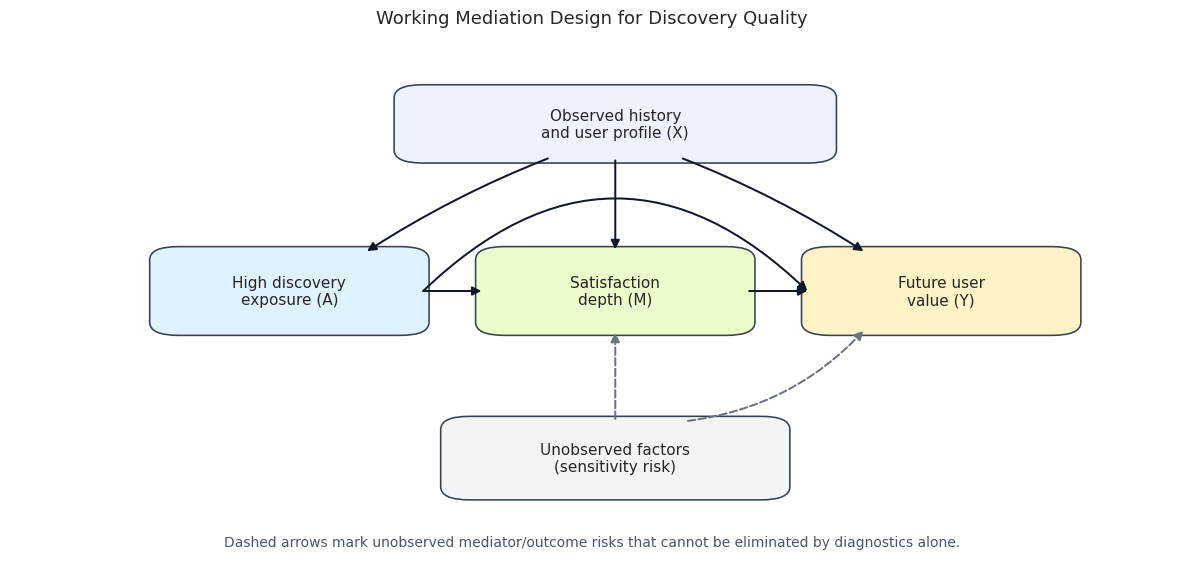

In [5]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# This layout keeps the main causal chain horizontal and places confounders
# above/below it, which prevents arrows from running through node labels.
positions = {
    "X": (0.52, 0.86),
    "A": (0.24, 0.54),
    "M": (0.52, 0.54),
    "Y": (0.80, 0.54),
    "U": (0.52, 0.22),
}
box_sizes = {
    "X": (0.34, 0.11),
    "A": (0.20, 0.13),
    "M": (0.20, 0.13),
    "Y": (0.20, 0.13),
    "U": (0.26, 0.12),
}
labels = {
    "X": "Observed history\nand user profile (X)",
    "A": "High discovery\nexposure (A)",
    "M": "Satisfaction\ndepth (M)",
    "Y": "Future user\nvalue (Y)",
    "U": "Unobserved factors\n(sensitivity risk)",
}
colors = {
    "X": "#eef2ff",
    "A": "#e0f2fe",
    "M": "#ecfccb",
    "Y": "#fef3c7",
    "U": "#f3f4f6",
}

for node, (x, y) in positions.items():
    width, height = box_sizes[node]
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        facecolor=colors[node],
        edgecolor="#374151",
        linewidth=1.15,
        zorder=3,
    )
    ax.add_patch(patch)
    ax.text(x, y, labels[node], ha="center", va="center", fontsize=11, zorder=4)


def box_edge_point(source, target):
    """
    Find the edge point where an arrow should leave a diagram box.
    
    Idea
    ----
    The DAG drawing code uses this geometry helper so arrows connect boxes cleanly without starting from their centers.
    
    Parameters
    ----------
    source : object
        Source diagram node or box.
    target : object
        Target diagram node or box.
    
    Returns
    -------
    tuple[float, float]
        Coordinate pair on the edge of the source box.
    """
    sx, sy = positions[source]
    tx, ty = positions[target]
    width, height = box_sizes[source]
    dx = tx - sx
    dy = ty - sy
    if dx == 0 and dy == 0:
        return np.array([sx, sy], dtype=float)

    scale_x = (width / 2) / abs(dx) if dx != 0 else np.inf
    scale_y = (height / 2) / abs(dy) if dy != 0 else np.inf
    scale = min(scale_x, scale_y)
    return np.array([sx + dx * scale, sy + dy * scale], dtype=float)


def draw_arrow(source, target, style="solid", rad=0.0, color="#111827"):
    """
    Draw a styled arrow between two mediation-diagram boxes.
    
    Idea
    ----
    The helper centralizes arrow style, curvature, and color so the causal pathway diagram remains readable.
    
    Parameters
    ----------
    source : object
        Source diagram node or box.
    target : object
        Target diagram node or box.
    style : object
        Matplotlib arrow style.
    rad : object
        Curvature radius for the arrow path.
    color : object
        Arrow color.
    
    Returns
    -------
    matplotlib.patches.FancyArrowPatch
        Arrow patch added to the active axis.
    """
    start = box_edge_point(source, target)
    end = box_edge_point(target, source)
    direction = end - start
    distance = np.linalg.norm(direction)
    if distance > 0:
        unit = direction / distance
        gap = 0.015
        start = start + gap * unit
        end = end - gap * unit

    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="-|>",
            mutation_scale=13,
            color=color,
            linewidth=1.45,
            linestyle=style,
            connectionstyle=f"arc3,rad={rad}",
            shrinkA=0,
            shrinkB=0,
        ),
        zorder=5,
    )

# Observed adjustment paths from prior history/profile.
draw_arrow("X", "A", rad=0.05)
draw_arrow("X", "M", rad=0.0)
draw_arrow("X", "Y", rad=-0.05)

# Main mediation chain and direct treatment path.
draw_arrow("A", "M")
draw_arrow("M", "Y")
draw_arrow("A", "Y", rad=-0.48)

# Dashed arrows mark risks we cannot fully diagnose from observed logs.
draw_arrow("U", "M", style="--", color="#6b7280")
draw_arrow("U", "Y", style="--", rad=0.18, color="#6b7280")

ax.text(
    0.5,
    0.06,
    "Dashed arrows mark unobserved mediator/outcome risks that cannot be eliminated by diagnostics alone.",
    ha="center",
    va="center",
    fontsize=10,
    color="#4b5563",
)
ax.set_title("Working Mediation Design for Discovery Quality", pad=20)
plt.tight_layout()
plt.show()


The diagram makes the biggest limitation visible: mediator-outcome confounding is hard to rule out with observational data. The notebook can diagnose observed history and profile imbalance, but unobserved user intent or recommendation-system state remains a sensitivity issue.

### Choose the Confounder Set

This cell defines the observed covariates used for diagnostics and later adjustment. The set intentionally uses variables measured before or at the start of the user-day: recent activity, recent satisfaction, recent discovery, calendar time, and static user profile features. It avoids future outcomes and avoids the mediator itself as a treatment confounder.

In [6]:
# Choose the confounder set.
base_numeric_covariates = [
    "calendar_day_index",
    "lag_1_active_day",
    "prior_3day_active_day",
    "lag_1_interactions",
    "prior_3day_interactions",
    "lag_1_total_play_duration_sec",
    "prior_3day_total_play_duration_sec",
    "lag_1_valid_play_share",
    "prior_3day_valid_play_share",
    "lag_1_high_satisfaction_share",
    "prior_3day_high_satisfaction_share",
    "lag_1_discovery_candidate_share",
    "prior_3day_discovery_candidate_share",
    "recent_activity_score",
    "register_days",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
]
profile_onehot_covariates = [col for col in analysis_panel.columns if col.startswith("onehot_feat")]
numeric_covariates = [col for col in base_numeric_covariates + profile_onehot_covariates if col in analysis_panel.columns]

categorical_covariates = [
    col
    for col in [
        "user_active_degree",
        "follow_user_num_range",
        "fans_user_num_range",
        "friend_user_num_range",
        "register_days_range",
    ]
    if col in analysis_panel.columns
]

covariate_registry = pd.DataFrame(
    [
        {"covariate": col, "type": "numeric", "reason": "Observed pre-treatment history or user profile proxy."}
        for col in numeric_covariates
    ]
    + [
        {"covariate": col, "type": "categorical", "reason": "Observed user profile group used for adjustment diagnostics."}
        for col in categorical_covariates
    ]
)

covariate_quality = pd.DataFrame(
    {
        "covariate": numeric_covariates,
        "missing_rate": analysis_panel[numeric_covariates].isna().mean().values,
        "unique_values": [analysis_panel[col].nunique(dropna=True) for col in numeric_covariates],
        "std": [analysis_panel[col].std(skipna=True) for col in numeric_covariates],
    }
).sort_values(["missing_rate", "unique_values"], ascending=[False, True])

display(covariate_registry.head(30))
display(covariate_quality.head(20))
print(f"Numeric covariates: {len(numeric_covariates)}")
print(f"Categorical covariates: {len(categorical_covariates)}")


,covariate,type,reason
0,calendar_day_index,numeric,Observed pre-treatment history or user profile proxy.
1,lag_1_active_day,numeric,Observed pre-treatment history or user profile proxy.
2,prior_3day_active_day,numeric,Observed pre-treatment history or user profile proxy.
3,lag_1_interactions,numeric,Observed pre-treatment history or user profile proxy.
4,prior_3day_interactions,numeric,Observed pre-treatment history or user profile proxy.
5,lag_1_total_play_duration_sec,numeric,Observed pre-treatment history or user profile proxy.
6,prior_3day_total_play_duration_sec,numeric,Observed pre-treatment history or user profile proxy.
7,lag_1_valid_play_share,numeric,Observed pre-treatment history or user profile proxy.
8,prior_3day_valid_play_share,numeric,Observed pre-treatment history or user profile proxy.
9,lag_1_high_satisfaction_share,numeric,Observed pre-treatment history or user profile proxy.


,covariate,missing_rate,unique_values,std
25,onehot_feat4,0.013416,5,0.871144
18,is_lowactive_period,0.000000,1,0.000000
19,is_live_streamer,0.000000,1,0.000000
26,onehot_feat5,0.000000,1,0.000000
37,onehot_feat16,0.000000,1,0.000000
1,lag_1_active_day,0.000000,2,0.165480
20,is_video_author,0.000000,2,0.372318
21,onehot_feat0,0.000000,2,0.479864
27,onehot_feat6,0.000000,2,0.475767
32,onehot_feat11,0.000000,2,0.245073


Numeric covariates: 39
Categorical covariates: 5


The covariate set is broad enough to capture user activity history and static profile differences, but it is still observational. The most important practical check is whether these variables show strong imbalance between high-discovery and lower-discovery days.

#### 7. Build the Modeling Matrix

This cell prepares the matrix used for propensity and residual diagnostics. Numeric variables are median-imputed, categorical variables are one-hot encoded, and constant columns are removed. This matrix is only a diagnostic object here; the next notebook can reuse the saved analysis panel and choose a final estimator.

In [7]:
# Build the modeling matrix.
model_frame = analysis_panel[
    [
        "user_id",
        "event_date",
        "A_high_discovery",
        "M_satisfaction_depth",
        "Y_future_interactions",
        "Y_future_active_days",
        "Y_future_play_hours",
    ]
    + numeric_covariates
    + categorical_covariates
].copy()

for col in numeric_covariates:
    model_frame[col] = pd.to_numeric(model_frame[col], errors="coerce")
    model_frame[col] = model_frame[col].fillna(model_frame[col].median())

for col in categorical_covariates:
    model_frame[col] = model_frame[col].astype("string").fillna("missing")

numeric_matrix = model_frame[numeric_covariates]
categorical_matrix = pd.get_dummies(model_frame[categorical_covariates], drop_first=True, dtype=float)
X_design = pd.concat([numeric_matrix, categorical_matrix], axis=1)
X_design = X_design.loc[:, X_design.nunique(dropna=False) > 1]

design_summary = pd.DataFrame(
    {
        "item": ["analysis_rows", "numeric_covariates", "categorical_covariates", "encoded_design_columns", "treatment_rate"],
        "value": [
            len(model_frame),
            len(numeric_covariates),
            len(categorical_covariates),
            X_design.shape[1],
            model_frame["A_high_discovery"].mean(),
        ],
    }
)

display(design_summary)
display(X_design.head())


,item,value
0,analysis_rows,8199.000000
1,numeric_covariates,39.000000
2,categorical_covariates,5.000000
3,encoded_design_columns,54.000000
4,treatment_rate,0.500061


,calendar_day_index,lag_1_active_day,prior_3day_active_day,lag_1_interactions,prior_3day_interactions,lag_1_total_play_duration_sec,prior_3day_total_play_duration_sec,lag_1_valid_play_share,prior_3day_valid_play_share,lag_1_high_satisfaction_share,prior_3day_high_satisfaction_share,lag_1_discovery_candidate_share,prior_3day_discovery_candidate_share,recent_activity_score,register_days,follow_user_num,fans_user_num,friend_user_num,is_video_author,onehot_feat0,onehot_feat1,onehot_feat2,onehot_feat3,onehot_feat4,onehot_feat6,onehot_feat7,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat17,user_active_degree_full_active,user_active_degree_high_active,"follow_user_num_range_(10,50]","follow_user_num_range_(100,150]","follow_user_num_range_(150,250]","follow_user_num_range_(250,500]","follow_user_num_range_(50,100]",follow_user_num_range_0,follow_user_num_range_500+,"fans_user_num_range_[1,10)","fans_user_num_range_[10,100)","friend_user_num_range_[1,5)","friend_user_num_range_[30,60)","friend_user_num_range_[5,30)",register_days_range_31-60,register_days_range_366-730,register_days_range_61-90,register_days_range_730+,register_days_range_91-180
0,0,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,224,7,3,0,0,0,1,24,876,1.0,1,4,98,6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1.0,1.0,32.0,32.0,163.970,163.970,0.937500,0.937500,0.156250,0.156250,0.687500,0.687500,0.562990,224,7,3,0,0,0,1,24,876,1.0,1,4,98,6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1.0,2.0,20.0,52.0,130.986,294.956,0.950000,1.887500,0.350000,0.506250,0.450000,1.137500,0.639277,224,7,3,0,0,0,1,24,876,1.0,1,4,98,6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,1.0,3.0,16.0,68.0,100.920,395.876,1.000000,2.887500,0.187500,0.693750,0.437500,1.575000,0.681755,224,7,3,0,0,0,1,24,876,1.0,1,4,98,6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1.0,3.0,37.0,73.0,222.720,454.626,0.891892,2.841892,0.216216,0.753716,0.432432,1.319932,0.693019,224,7,3,0,0,0,1,24,876,1.0,1,4,98,6,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The encoded design matrix is now ready for overlap and balance checks. Because this is a setup notebook, the goal is to see whether observed covariates can reasonably support treated-versus-control comparisons.

### Estimate Propensity Scores for Overlap Diagnostics

This cell fits a logistic model for the probability of high discovery exposure given observed covariates. The propensity score is used to diagnose overlap: each row should have a non-extreme chance of being either high-discovery or lower-discovery after conditioning on observed history and profile variables.

In [8]:
# Estimate propensity scores for overlap diagnostics.
A = model_frame["A_high_discovery"].astype(int).to_numpy()

propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, solver="lbfgs"),
)
propensity_model.fit(X_design, A)

analysis_panel["propensity_high_discovery"] = propensity_model.predict_proba(X_design)[:, 1]
analysis_panel["propensity_high_discovery_clipped"] = analysis_panel["propensity_high_discovery"].clip(0.02, 0.98)

treatment_rate = analysis_panel["A_high_discovery"].mean()
analysis_panel["stabilized_ipw"] = np.where(
    analysis_panel["A_high_discovery"].eq(1),
    treatment_rate / analysis_panel["propensity_high_discovery_clipped"],
    (1 - treatment_rate) / (1 - analysis_panel["propensity_high_discovery_clipped"]),
)
analysis_panel["stabilized_ipw_capped"] = analysis_panel["stabilized_ipw"].clip(
    upper=analysis_panel["stabilized_ipw"].quantile(0.99)
)

weight = analysis_panel["stabilized_ipw_capped"].to_numpy()
overlap_summary = pd.DataFrame(
    {
        "diagnostic": [
            "treatment_rate",
            "propensity_min",
            "propensity_p01",
            "propensity_p05",
            "propensity_median",
            "propensity_p95",
            "propensity_p99",
            "propensity_max",
            "share_propensity_below_0_05",
            "share_propensity_above_0_95",
            "capped_weight_mean",
            "capped_weight_max",
            "effective_sample_size",
        ],
        "value": [
            treatment_rate,
            analysis_panel["propensity_high_discovery"].min(),
            analysis_panel["propensity_high_discovery"].quantile(0.01),
            analysis_panel["propensity_high_discovery"].quantile(0.05),
            analysis_panel["propensity_high_discovery"].median(),
            analysis_panel["propensity_high_discovery"].quantile(0.95),
            analysis_panel["propensity_high_discovery"].quantile(0.99),
            analysis_panel["propensity_high_discovery"].max(),
            (analysis_panel["propensity_high_discovery"] < 0.05).mean(),
            (analysis_panel["propensity_high_discovery"] > 0.95).mean(),
            analysis_panel["stabilized_ipw_capped"].mean(),
            analysis_panel["stabilized_ipw_capped"].max(),
            weight.sum() ** 2 / np.square(weight).sum(),
        ],
    }
)

display(overlap_summary.round(4))


,diagnostic,value
0,treatment_rate,0.5001
1,propensity_min,0.0189
2,propensity_p01,0.0290
3,propensity_p05,0.0420
4,propensity_median,0.5744
5,propensity_p95,0.8596
6,propensity_p99,0.9303
7,propensity_max,0.9824
8,share_propensity_below_0_05,0.0698
9,share_propensity_above_0_95,0.0017


The overlap diagnostics tell us whether high-discovery and lower-discovery days occupy comparable covariate regions. Extreme propensities would be a warning that later effect estimates depend on extrapolation.

#### 9. Visualize Propensity Overlap

This cell plots the propensity score distributions separately for lower-discovery and high-discovery days. Good overlap means the two distributions share substantial support.

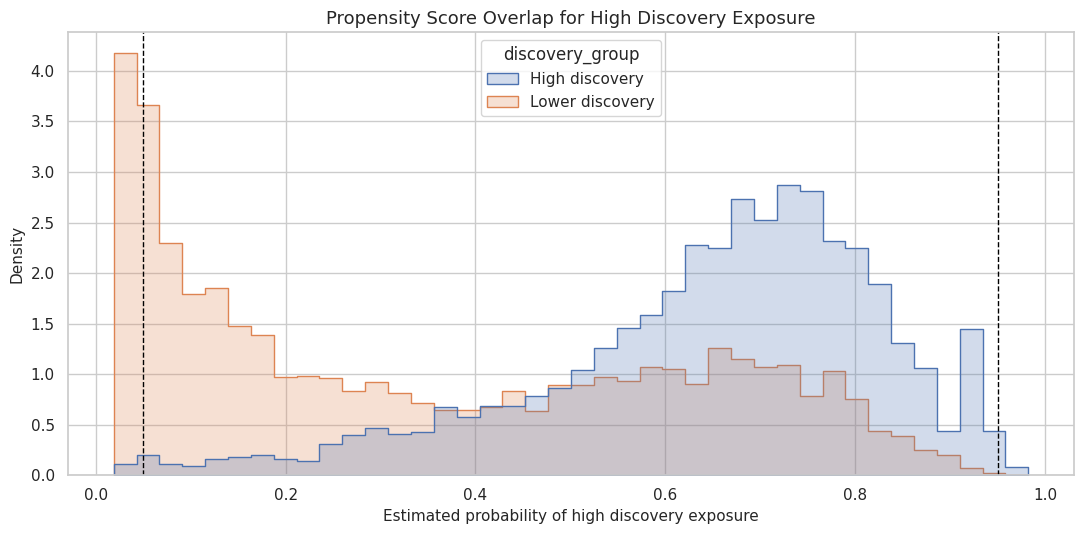

In [9]:
# Visualize propensity overlap.
propensity_plot = analysis_panel[["A_high_discovery", "propensity_high_discovery"]].copy()
propensity_plot["discovery_group"] = propensity_plot["A_high_discovery"].map(
    {0: "Lower discovery", 1: "High discovery"}
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.histplot(
    data=propensity_plot,
    x="propensity_high_discovery",
    hue="discovery_group",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
    ax=ax,
)
ax.axvline(0.05, color="black", linestyle="--", linewidth=1)
ax.axvline(0.95, color="black", linestyle="--", linewidth=1)
ax.set_title("Propensity Score Overlap for High Discovery Exposure")
ax.set_xlabel("Estimated probability of high discovery exposure")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()


The figure gives a more intuitive version of the overlap table. If most observations sit away from 0 and 1, the next notebook can estimate effects with less concern about positivity failure.

### Check Covariate Balance Before and After Weighting

This cell computes standardized mean differences for numeric covariates before and after applying capped stabilized inverse-probability weights. Balance shows whether observed covariate differences are reduced by the proposed adjustment strategy.

In [10]:
# Check covariate balance before and after weighting.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.average(values, weights=weights)


def weighted_var(values, weights):
    """
    Compute a weighted variance for balance and uncertainty diagnostics.
    
    Idea
    ----
    The calculation supports weighted standardized mean differences by measuring spread under the same weighting scheme used for adjustment.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted variance of the non-missing values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = weighted_mean(values, weights)
    return np.average((values - mean) ** 2, weights=weights)


def standardized_mean_difference(frame, column, treatment_col, weight_col=None):
    """
    Compute a standardized mean difference for one covariate.
    
    Idea
    ----
    The helper compares treated and control covariate means, optionally under weights, to diagnose observed imbalance in the causal design.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    column : object
        Name of the column being transformed or summarized.
    treatment_col : object
        Column indicating treatment or exposure status.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    float
        Standardized mean difference for the requested column.
    """
    treated = frame[treatment_col].eq(1)
    control = frame[treatment_col].eq(0)
    x_t = frame.loc[treated, column].astype(float)
    x_c = frame.loc[control, column].astype(float)

    if weight_col is None:
        mean_t = x_t.mean()
        mean_c = x_c.mean()
        var_t = x_t.var(ddof=0)
        var_c = x_c.var(ddof=0)
    else:
        w_t = frame.loc[treated, weight_col].astype(float)
        w_c = frame.loc[control, weight_col].astype(float)
        mean_t = weighted_mean(x_t, w_t)
        mean_c = weighted_mean(x_c, w_c)
        var_t = weighted_var(x_t, w_t)
        var_c = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((var_t + var_c) / 2)
    if np.isclose(pooled_sd, 0):
        smd = 0.0
    else:
        smd = (mean_t - mean_c) / pooled_sd
    return mean_t, mean_c, smd

balance_rows = []
for col in numeric_covariates:
    if analysis_panel[col].nunique(dropna=True) < 2:
        continue
    untreated_mean_t, untreated_mean_c, unweighted_smd = standardized_mean_difference(
        analysis_panel, col, "A_high_discovery"
    )
    weighted_mean_t, weighted_mean_c, weighted_smd = standardized_mean_difference(
        analysis_panel, col, "A_high_discovery", "stabilized_ipw_capped"
    )
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": untreated_mean_t,
            "control_mean": untreated_mean_c,
            "unweighted_smd": unweighted_smd,
            "weighted_treated_mean": weighted_mean_t,
            "weighted_control_mean": weighted_mean_c,
            "weighted_smd": weighted_smd,
            "abs_unweighted_smd": abs(unweighted_smd),
            "abs_weighted_smd": abs(weighted_smd),
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("abs_unweighted_smd", ascending=False)
balance_summary = pd.DataFrame(
    {
        "diagnostic": [
            "max_abs_unweighted_smd",
            "max_abs_weighted_smd",
            "mean_abs_unweighted_smd",
            "mean_abs_weighted_smd",
            "covariates_abs_weighted_smd_above_0_10",
            "covariates_abs_weighted_smd_above_0_25",
        ],
        "value": [
            balance_table["abs_unweighted_smd"].max(),
            balance_table["abs_weighted_smd"].max(),
            balance_table["abs_unweighted_smd"].mean(),
            balance_table["abs_weighted_smd"].mean(),
            (balance_table["abs_weighted_smd"] > 0.10).sum(),
            (balance_table["abs_weighted_smd"] > 0.25).sum(),
        ],
    }
)

display(balance_summary.round(4))
display(balance_table.head(15).round(4))


,diagnostic,value
0,max_abs_unweighted_smd,0.9606
1,max_abs_weighted_smd,0.1570
2,mean_abs_unweighted_smd,0.1812
3,mean_abs_weighted_smd,0.0366
4,covariates_abs_weighted_smd_above_0_10,3.0000
5,covariates_abs_weighted_smd_above_0_25,0.0000


,covariate,treated_mean,control_mean,unweighted_smd,weighted_treated_mean,weighted_control_mean,weighted_smd,abs_unweighted_smd,abs_weighted_smd
0,calendar_day_index,22.9912,38.6045,-0.9606,27.4693,30.1885,-0.1570,0.9606,0.1570
11,lag_1_discovery_candidate_share,0.4288,0.2884,0.8709,0.3887,0.3676,0.1263,0.8709,0.1263
12,prior_3day_discovery_candidate_share,1.2457,0.8955,0.8697,1.1513,1.0962,0.1354,0.8697,0.1354
4,prior_3day_interactions,177.0871,128.0707,0.6520,162.6857,155.8037,0.0874,0.6520,0.0874
3,lag_1_interactions,60.1893,41.8717,0.5952,54.8213,52.5795,0.0689,0.5952,0.0689
6,prior_3day_total_play_duration_sec,1524.3921,1118.6594,0.5652,1403.9316,1342.6616,0.0828,0.5652,0.0828
5,lag_1_total_play_duration_sec,518.4572,365.8509,0.5229,472.1447,452.3735,0.0653,0.5229,0.0653
13,recent_activity_score,0.7937,0.7544,0.2760,0.7857,0.7837,0.0150,0.2760,0.0150
2,prior_3day_active_day,2.8105,2.9234,-0.2242,2.8586,2.8947,-0.0762,0.2242,0.0762
8,prior_3day_valid_play_share,2.6390,2.7446,-0.1992,2.6774,2.7155,-0.0755,0.1992,0.0755


The balance table identifies which observed histories differ most across high-discovery and lower-discovery days. If weighting reduces the largest standardized differences, it supports using these covariates in later adjusted estimators.

#### 11. Plot the Largest Balance Gaps

This cell visualizes the largest standardized mean differences. The dashed reference lines at +/-0.10 are common practical thresholds for small imbalance. They help communicate whether the adjustment is doing useful work.

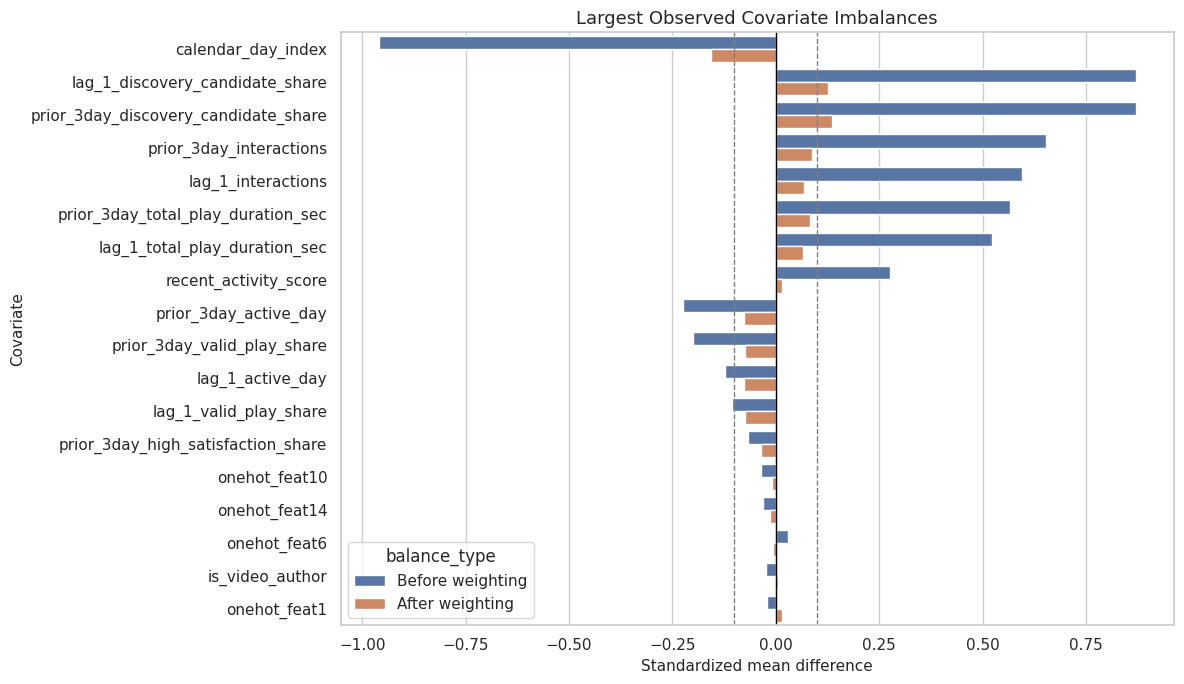

In [11]:
# Plot the largest balance gaps.
balance_plot = balance_table.head(18).copy()
balance_plot_long = balance_plot.melt(
    id_vars="covariate",
    value_vars=["unweighted_smd", "weighted_smd"],
    var_name="balance_type",
    value_name="smd",
)
balance_plot_long["balance_type"] = balance_plot_long["balance_type"].map(
    {"unweighted_smd": "Before weighting", "weighted_smd": "After weighting"}
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=balance_plot_long,
    x="smd",
    y="covariate",
    hue="balance_type",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.10, color="gray", linestyle="--", linewidth=1)
ax.axvline(-0.10, color="gray", linestyle="--", linewidth=1)
ax.set_title("Largest Observed Covariate Imbalances")
ax.set_xlabel("Standardized mean difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
plt.show()


This plot is the most compact balance diagnostic for a reader. It shows both the raw observational imbalance and how much the proposed weighting scheme reduces that imbalance.

### Inspect Treatment, Mediator, and Outcome Relationships

This cell summarizes how the mediator and future outcomes differ by treatment group. These raw relationships provide setup checks for the proposed mediation pathway. They provide the first check that the proposed mediation pathway has the right ingredients: treatment is related to the mediator, mediator is related to outcome, and treatment is related to outcome.

In [12]:
# Inspect treatment, mediator, and outcome relationships.
group_summary = (
    analysis_panel.groupby("A_high_discovery")
    .agg(
        user_days=("user_id", "size"),
        users=("user_id", "nunique"),
        discovery_score_mean=("discovery_breadth_score", "mean"),
        mediator_mean=("M_satisfaction_depth", "mean"),
        future_interactions_mean=("Y_future_interactions", "mean"),
        future_active_days_mean=("Y_future_active_days", "mean"),
        future_play_hours_mean=("Y_future_play_hours", "mean"),
        prior_interactions_mean=("prior_3day_interactions", "mean"),
    )
    .reset_index()
)
group_summary["group"] = group_summary["A_high_discovery"].map({0: "Lower discovery", 1: "High discovery"})

difference_row = pd.DataFrame(
    [
        {
            "comparison": "high_minus_lower",
            "mediator_difference": group_summary.loc[group_summary["A_high_discovery"].eq(1), "mediator_mean"].iloc[0]
            - group_summary.loc[group_summary["A_high_discovery"].eq(0), "mediator_mean"].iloc[0],
            "future_interactions_difference": group_summary.loc[group_summary["A_high_discovery"].eq(1), "future_interactions_mean"].iloc[0]
            - group_summary.loc[group_summary["A_high_discovery"].eq(0), "future_interactions_mean"].iloc[0],
            "future_active_days_difference": group_summary.loc[group_summary["A_high_discovery"].eq(1), "future_active_days_mean"].iloc[0]
            - group_summary.loc[group_summary["A_high_discovery"].eq(0), "future_active_days_mean"].iloc[0],
            "prior_interactions_difference": group_summary.loc[group_summary["A_high_discovery"].eq(1), "prior_interactions_mean"].iloc[0]
            - group_summary.loc[group_summary["A_high_discovery"].eq(0), "prior_interactions_mean"].iloc[0],
        }
    ]
)

pathway_correlations = pd.DataFrame(
    [
        {
            "relationship": "A with M",
            "spearman_corr": analysis_panel["A_high_discovery"].corr(analysis_panel["M_satisfaction_depth"], method="spearman"),
        },
        {
            "relationship": "A with Y",
            "spearman_corr": analysis_panel["A_high_discovery"].corr(analysis_panel["Y_future_interactions"], method="spearman"),
        },
        {
            "relationship": "M with Y",
            "spearman_corr": analysis_panel["M_satisfaction_depth"].corr(analysis_panel["Y_future_interactions"], method="spearman"),
        },
        {
            "relationship": "Discovery score with M",
            "spearman_corr": analysis_panel["discovery_breadth_score"].corr(analysis_panel["M_satisfaction_depth"], method="spearman"),
        },
        {
            "relationship": "Discovery score with Y",
            "spearman_corr": analysis_panel["discovery_breadth_score"].corr(analysis_panel["Y_future_interactions"], method="spearman"),
        },
    ]
)

display(group_summary.round(4))
display(difference_row.round(4))
display(pathway_correlations.round(4))


,A_high_discovery,user_days,users,discovery_score_mean,mediator_mean,future_interactions_mean,future_active_days_mean,future_play_hours_mean,prior_interactions_mean,group
0,0,4099,133,0.2207,0.6103,252.4708,6.0756,0.6149,128.0707,Lower discovery
1,1,4100,133,0.4099,0.6269,428.8966,6.8571,1.0229,177.0871,High discovery


,comparison,mediator_difference,future_interactions_difference,future_active_days_difference,prior_interactions_difference
0,high_minus_lower,0.0166,176.4257,0.7814,49.0163


,relationship,spearman_corr
0,A with M,0.0927
1,A with Y,0.4740
2,M with Y,0.0094
3,Discovery score with M,0.0930
4,Discovery score with Y,0.5674


The raw summaries are useful and preliminary. A large future-outcome gap could reflect discovery exposure, pre-existing user activity, or both. That is why the notebook pairs these summaries with balance and overlap checks.

#### 13. Visualize the Mediation Pathway Ingredients

This cell plots the mediator and future outcome by treatment group. The purpose is to make the proposed pathway concrete: high discovery exposure should have a visible relationship with satisfaction depth and future value if mediation analysis is worth pursuing.

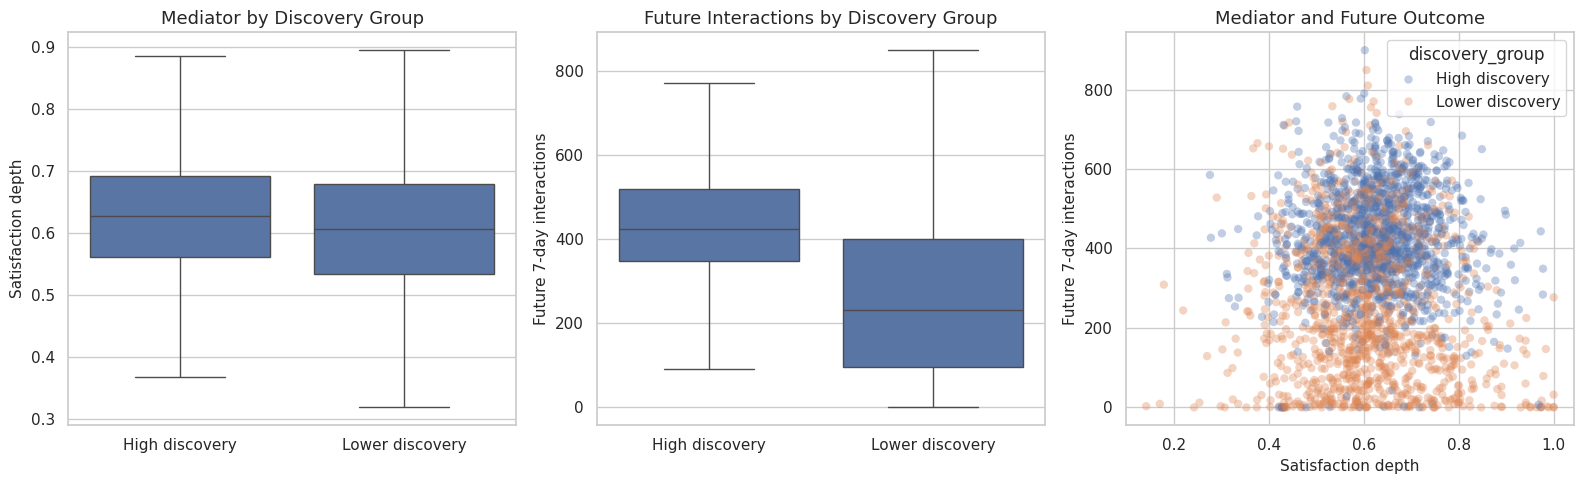

In [13]:
# Visualize the mediation pathway ingredients.
pathway_plot = analysis_panel.copy()
pathway_plot["discovery_group"] = pathway_plot["A_high_discovery"].map(
    {0: "Lower discovery", 1: "High discovery"}
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=pathway_plot,
    x="discovery_group",
    y="M_satisfaction_depth",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Mediator by Discovery Group")
axes[0].set_xlabel("")
axes[0].set_ylabel("Satisfaction depth")

sns.boxplot(
    data=pathway_plot,
    x="discovery_group",
    y="Y_future_interactions",
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Future Interactions by Discovery Group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Future 7-day interactions")

sns.scatterplot(
    data=pathway_plot.sample(min(len(pathway_plot), 2500), random_state=42),
    x="M_satisfaction_depth",
    y="Y_future_interactions",
    hue="discovery_group",
    alpha=0.35,
    linewidth=0,
    ax=axes[2],
)
axes[2].set_title("Mediator and Future Outcome")
axes[2].set_xlabel("Satisfaction depth")
axes[2].set_ylabel("Future 7-day interactions")

plt.tight_layout()
plt.show()


The pathway plots are descriptive. They help explain why the next notebook estimates total, direct, and indirect effects.

#### 14. Residualize the Mediator-Outcome Relationship

A mediator-outcome relationship can be confounded by user history. This cell residualizes both the mediator and the primary outcome on observed covariates, then checks whether the residualized mediator and residualized outcome still move together. This is a helpful diagnostic before formal mediation estimation.

In [14]:
residual_model_m = make_pipeline(StandardScaler(), LinearRegression())
residual_model_y = make_pipeline(StandardScaler(), LinearRegression())

residual_model_m.fit(X_design, analysis_panel["M_satisfaction_depth"])
residual_model_y.fit(X_design, analysis_panel["Y_future_interactions"])

analysis_panel["M_residual_after_X"] = analysis_panel["M_satisfaction_depth"] - residual_model_m.predict(X_design)
analysis_panel["Y_residual_after_X"] = analysis_panel["Y_future_interactions"] - residual_model_y.predict(X_design)

residual_diagnostics = pd.DataFrame(
    [
        {
            "relationship": "raw M with Y",
            "pearson_corr": analysis_panel["M_satisfaction_depth"].corr(analysis_panel["Y_future_interactions"]),
            "spearman_corr": analysis_panel["M_satisfaction_depth"].corr(analysis_panel["Y_future_interactions"], method="spearman"),
        },
        {
            "relationship": "M residual with Y residual after X",
            "pearson_corr": analysis_panel["M_residual_after_X"].corr(analysis_panel["Y_residual_after_X"]),
            "spearman_corr": analysis_panel["M_residual_after_X"].corr(analysis_panel["Y_residual_after_X"], method="spearman"),
        },
    ]
)

display(residual_diagnostics.round(4))


,relationship,pearson_corr,spearman_corr
0,raw M with Y,-0.0265,0.0094
1,M residual with Y residual after X,-0.0212,-0.0192


If the residualized mediator-outcome relationship remains meaningful, it supports carrying the mediator forward into effect decomposition. If it nearly disappears, the later indirect-effect estimate may be small or sensitive to adjustment choices.

### Define the Estimation Blueprint

This cell writes the model blueprint for the next notebook. The blueprint is intentionally explicit: estimate the total effect model, estimate a mediator model, then estimate an outcome model that includes treatment, mediator, their interaction, and covariates. Those pieces allow g-computation for total, direct, and indirect effects.

In [15]:
# Define the estimation blueprint.
model_blueprint = pd.DataFrame(
    [
        {
            "model_step": "total_effect_model",
            "target": "Y_future_interactions",
            "formula_concept": "Y ~ A + X",
            "purpose": "Estimate the overall association of high discovery exposure with future value after observed adjustment.",
        },
        {
            "model_step": "mediator_model",
            "target": "M_satisfaction_depth",
            "formula_concept": "M ~ A + X",
            "purpose": "Estimate how high discovery exposure shifts satisfaction depth after observed adjustment.",
        },
        {
            "model_step": "outcome_mediation_model",
            "target": "Y_future_interactions",
            "formula_concept": "Y ~ A + M + A*M + X",
            "purpose": "Estimate how treatment and mediator jointly predict future value after observed adjustment.",
        },
        {
            "model_step": "counterfactual_prediction",
            "target": "Y(a, M(a_prime))",
            "formula_concept": "Predict mediator under A=0/1, then predict outcome under treatment-mediator combinations.",
            "purpose": "Compute total, natural direct, natural indirect, and controlled direct effects by averaging predictions.",
        },
        {
            "model_step": "bootstrap_uncertainty",
            "target": "effect intervals",
            "formula_concept": "Resample users, not rows, to respect repeated user-days.",
            "purpose": "Quantify uncertainty while acknowledging clustered user-day observations.",
        },
    ]
)

display(model_blueprint)


,model_step,target,formula_concept,purpose
0,total_effect_model,Y_future_interactions,Y ~ A + X,Estimate the overall association of high discovery exposure with future value after observed adjustment.
1,mediator_model,M_satisfaction_depth,M ~ A + X,Estimate how high discovery exposure shifts satisfaction depth after observed adjustment.
2,outcome_mediation_model,Y_future_interactions,Y ~ A + M + A*M + X,Estimate how treatment and mediator jointly predict future value after observed adjustment.
3,counterfactual_prediction,"Y(a, M(a_prime))","Predict mediator under A=0/1, then predict outcome under treatment-mediator combinations.","Compute total, natural direct, natural indirect, and controlled direct effects by averaging predictions."
4,bootstrap_uncertainty,effect intervals,"Resample users, not rows, to respect repeated user-days.",Quantify uncertainty while acknowledging clustered user-day observations.


The blueprint also names the right resampling unit: users. Since each user contributes many days, row-level bootstrap would overstate precision. User-level resampling is a cleaner default for uncertainty in the next notebook.

### Compile Assumption Checks

This cell collects the main assumptions and the available diagnostics into one table. Some assumptions are testable only indirectly, and some remain untestable from observational data. The value of the table is honesty: it separates what the notebook checked from what must remain a limitation.

In [16]:
# Compile assumption checks.
assumption_checks = pd.DataFrame(
    [
        {
            "assumption": "consistency",
            "status": "design_definition",
            "diagnostic": "Treatment, mediator, and outcome are defined at the user-day level with no future information in A or M.",
            "value": "A=high discovery day; M=satisfaction depth; Y=future 7-day interactions",
            "risk_if_violated": "Effects would mix incompatible versions of discovery exposure.",
        },
        {
            "assumption": "positivity_overlap",
            "status": "checked",
            "diagnostic": "Propensity score support and extreme propensity shares.",
            "value": f"p05={analysis_panel['propensity_high_discovery'].quantile(0.05):.3f}, p95={analysis_panel['propensity_high_discovery'].quantile(0.95):.3f}",
            "risk_if_violated": "Estimates would rely on extrapolating to user-days with little comparable data.",
        },
        {
            "assumption": "observed_treatment_exchangeability",
            "status": "partially_checked",
            "diagnostic": "Numeric covariate balance before and after capped stabilized weighting.",
            "value": f"max weighted abs SMD={balance_table['abs_weighted_smd'].max():.3f}",
            "risk_if_violated": "The high-discovery contrast could reflect user history.",
        },
        {
            "assumption": "observed_mediator_outcome_adjustment",
            "status": "partially_checked",
            "diagnostic": "Residual mediator-outcome relationship after observed covariates.",
            "value": f"residual Spearman={residual_diagnostics.loc[1, 'spearman_corr']:.3f}",
            "risk_if_violated": "The indirect pathway could be confounded by unmeasured user intent or recommendation state.",
        },
        {
            "assumption": "no_unmeasured_confounding",
            "status": "not_testable",
            "diagnostic": "Requires domain argument and sensitivity analysis.",
            "value": "Not guaranteed by observational KuaiRec logs.",
            "risk_if_violated": "Direct and indirect effects may not support a causal reading.",
        },
        {
            "assumption": "no_treatment_induced_mediator_outcome_confounder",
            "status": "not_testable",
            "diagnostic": "Requires design argument; avoid adjusting for post-treatment variables affected by A.",
            "value": "Use pre-treatment history/profile controls in primary setup.",
            "risk_if_violated": "Mediation decomposition can be biased even if treatment and mediator models fit well.",
        },
    ]
)

display(assumption_checks)


,assumption,status,diagnostic,value,risk_if_violated
0,consistency,design_definition,"Treatment, mediator, and outcome are defined at the user-day level with no future information in A or M.",A=high discovery day; M=satisfaction depth; Y=future 7-day interactions,Effects would mix incompatible versions of discovery exposure.
1,positivity_overlap,checked,Propensity score support and extreme propensity shares.,"p05=0.042, p95=0.860",Estimates would rely on extrapolating to user-days with little comparable data.
2,observed_treatment_exchangeability,partially_checked,Numeric covariate balance before and after capped stabilized weighting.,max weighted abs SMD=0.157,The high-discovery contrast could reflect user history.
3,observed_mediator_outcome_adjustment,partially_checked,Residual mediator-outcome relationship after observed covariates.,residual Spearman=-0.019,The indirect pathway could be confounded by unmeasured user intent or recommendation state.
4,no_unmeasured_confounding,not_testable,Requires domain argument and sensitivity analysis.,Not guaranteed by observational KuaiRec logs.,Direct and indirect effects may not support a causal reading.
5,no_treatment_induced_mediator_outcome_confounder,not_testable,Requires design argument; avoid adjusting for post-treatment variables affected by A.,Use pre-treatment history/profile controls in primary setup.,Mediation decomposition can be biased even if treatment and mediator models fit well.


This table is the bridge from exploratory diagnostics to causal estimation. It says the data are usable for a careful observational mediation exercise, while keeping the key limitations visible.

In [ ]:
#| include: false
# Save the mediation setup artifacts.
analysis_panel.to_parquet(MEDIATION_ANALYSIS_OUTPUT, index=False)
estimand_registry.to_csv(ESTIMAND_REGISTRY_OUTPUT, index=False)
assumption_checks.to_csv(ASSUMPTION_CHECKS_OUTPUT, index=False)
balance_table.to_csv(BALANCE_TABLE_OUTPUT, index=False)
overlap_summary.to_csv(OVERLAP_SUMMARY_OUTPUT, index=False)
model_blueprint.to_csv(MODEL_BLUEPRINT_OUTPUT, index=False)


The saved panel now contains `A_high_discovery`, `M_satisfaction_depth`, future outcomes, propensities, capped stabilized weights, and residual diagnostics. That is enough structure for the next notebook to estimate direct, indirect, and total effects cleanly.

### Takeaways and Next Step

This notebook established the mediation design for discovery quality:

- Treatment is high discovery breadth, measured before the future outcome window.
- Mediator is same-day satisfaction depth, treated as the pathway variable.
- Primary outcome is future seven-day interactions, with active days and play hours as alternates.
- The estimands are total effect, natural direct effect, natural indirect effect, and controlled direct effects.
- Overlap and observed balance are good enough to proceed, but unobserved mediator-outcome confounding remains a limitation.

The next notebook should estimate the direct, indirect, and total effects using the saved mediation analysis panel.